In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np 
import statsmodels.api as sm
from statsmodels.formula.api import ols
from scipy.stats import kruskal
from scipy import stats
import scikit_posthocs as sp


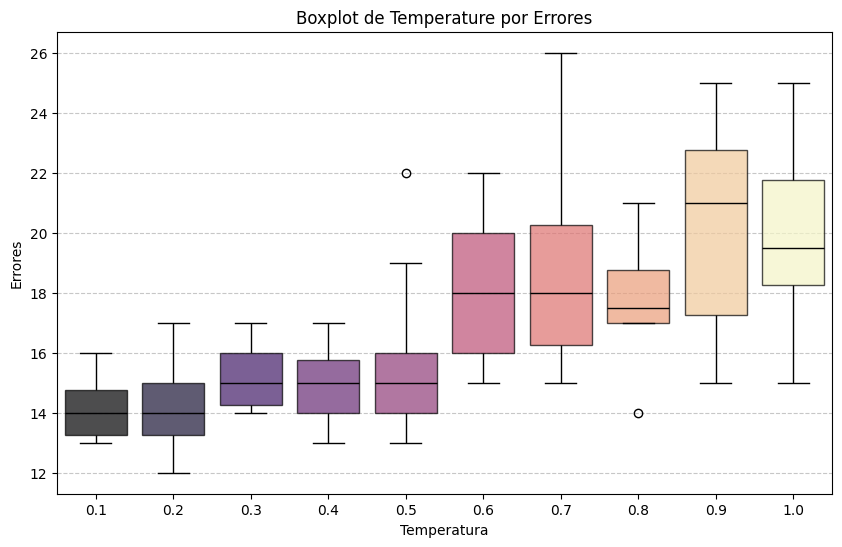

In [7]:
data = pd.read_excel('temp vs errores.xlsx')

plt.figure(figsize=(10, 6))
sns.boxplot(x='temp', y='errores', data=data, hue= 'temp', showmeans=False, palette='magma', legend=False,
                                        boxprops=dict( 
                                            alpha=0.7,
                                            linewidth=1,
                                            edgecolor='black') ,                            
                                         whiskerprops=dict(color='black', 
                                            linewidth=1,
                                            linestyle='-'),)

plt.title('Boxplot de Temperature por Errores')
plt.xlabel('Temperatura')
plt.ylabel('Errores')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

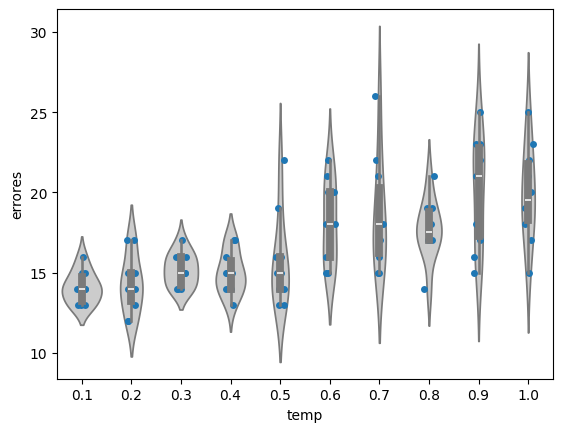

In [ ]:
#violin plot with jitter
colores = plt.rcParams['axes.prop_cycle'].by_key()['color']
sns.violinplot(x="temp", y="errores", data=data, color="0.8")
sns.stripplot(x="temp", y="errores", data=data, jitter=True, zorder=1)
plt.show()

In [ ]:
#test de Wilcoxon -- HIPOTESIS NULA: no hay diferencia entre las medianas
#                 -- HIPOTESIS ALTERNATIVA: existe una diferencia 
data_error = [
        [15, 13, 14, 16, 14, 14, 15, 13, 14, 13], # temp 0.1
        [15, 17, 15, 13, 17, 14, 14, 12, 14, 12],  # temp 0.2
        [15, 17, 16, 16, 16, 14, 15, 15, 14, 14],  # temp 0.3
        [16, 15, 17, 14, 14, 17, 15, 13, 14, 15],  # temp 0.4
        [13, 15, 19, 14, 16, 14, 15, 16, 22, 13],  # temp 0.5
        [15, 22, 20, 16, 21, 18, 16, 18, 20, 15],  # temp 0.6
        [21, 26, 16, 18, 17, 18, 22, 15, 18, 15],  # temp 0.7
        [21, 19, 14, 17, 17, 18, 17, 18, 19, 17],  # temp 0.8
        [21, 18, 23, 16, 15, 22, 21, 23, 25, 17],  # temp 0.9
        [19, 22, 15, 21, 20, 25, 17, 18, 19, 23]   # temp 1.0
    ]

resultados = []

for i in range(1, len(data_error)):
            statistic, p_value = stats.wilcoxon(data_error[0], data_error[i])
            
            media_0 = np.mean(data_error[0])
            media_actual = np.mean(data_error[i])
            dif_media = media_actual - media_0


          
            resultados.append({
                    'Media_A': media_0,
                    'Media_B': media_actual,
                    'Diferencia_medias': dif_media,
                    'Estadistico_W': statistic,
                    'Valor_p': p_value,
                    'Significativo_0.05': p_value < 0.05
                })
            print(f"\n--- Resultados del Test de Wilcoxon temp0.1 vs temp0.{i+1}---")
            print(f"Estadístico: {statistic}")
            print(f"Valor p: {p_value:.4f}")

df_resultados = pd.DataFrame(resultados)            
print(df_resultados.round(4))


#alpha = 0.05 # nivel de significancia que se establece para tomar decision



--- Resultados del Test de Wilcoxon temp0.1 vs temp0.2---
Estadístico: 13.0
Valor p: 0.9375

--- Resultados del Test de Wilcoxon temp0.1 vs temp0.3---
Estadístico: 0.0
Valor p: 0.0625

--- Resultados del Test de Wilcoxon temp0.1 vs temp0.4---
Estadístico: 3.0
Valor p: 0.1562

--- Resultados del Test de Wilcoxon temp0.1 vs temp0.5---
Estadístico: 5.0
Valor p: 0.1875

--- Resultados del Test de Wilcoxon temp0.1 vs temp0.6---
Estadístico: 0.0
Valor p: 0.0078

--- Resultados del Test de Wilcoxon temp0.1 vs temp0.7---
Estadístico: 0.0
Valor p: 0.0020

--- Resultados del Test de Wilcoxon temp0.1 vs temp0.8---
Estadístico: 0.0
Valor p: 0.0039

--- Resultados del Test de Wilcoxon temp0.1 vs temp0.9---
Estadístico: 0.0
Valor p: 0.0039

--- Resultados del Test de Wilcoxon temp0.1 vs temp0.10---
Estadístico: 0.0
Valor p: 0.0020
   Media_A  Media_B  Diferencia_medias  Estadistico_W  Valor_p  \
0     14.1     14.3                0.2           13.0   0.9375   
1     14.1     15.2                1.1

=== MATRIZ DE VALORES p (Triángulo Superior) ===
          temp0.1  temp0.2  temp0.3  temp0.4  temp0.5  temp0.6  temp0.7  \
temp0.1       NaN   0.9375   0.0625   0.1562   0.1875   0.0078   0.0020   
temp0.2       NaN      NaN   0.1250   0.3516   0.3203   0.0039   0.0039   
temp0.3       NaN      NaN      NaN   0.5938   0.9531   0.0078   0.0078   
temp0.4       NaN      NaN      NaN      NaN   0.8438   0.0156   0.0117   
temp0.5       NaN      NaN      NaN      NaN      NaN   0.0176   0.1113   
temp0.6       NaN      NaN      NaN      NaN      NaN      NaN   0.6797   
temp0.7       NaN      NaN      NaN      NaN      NaN      NaN      NaN   
temp0.8       NaN      NaN      NaN      NaN      NaN      NaN      NaN   
temp0.9       NaN      NaN      NaN      NaN      NaN      NaN      NaN   
temp0.10      NaN      NaN      NaN      NaN      NaN      NaN      NaN   

          temp0.8  temp0.9  temp0.10  
temp0.1    0.0039   0.0039    0.0020  
temp0.2    0.0078   0.0059    0.0039  
temp0.3 

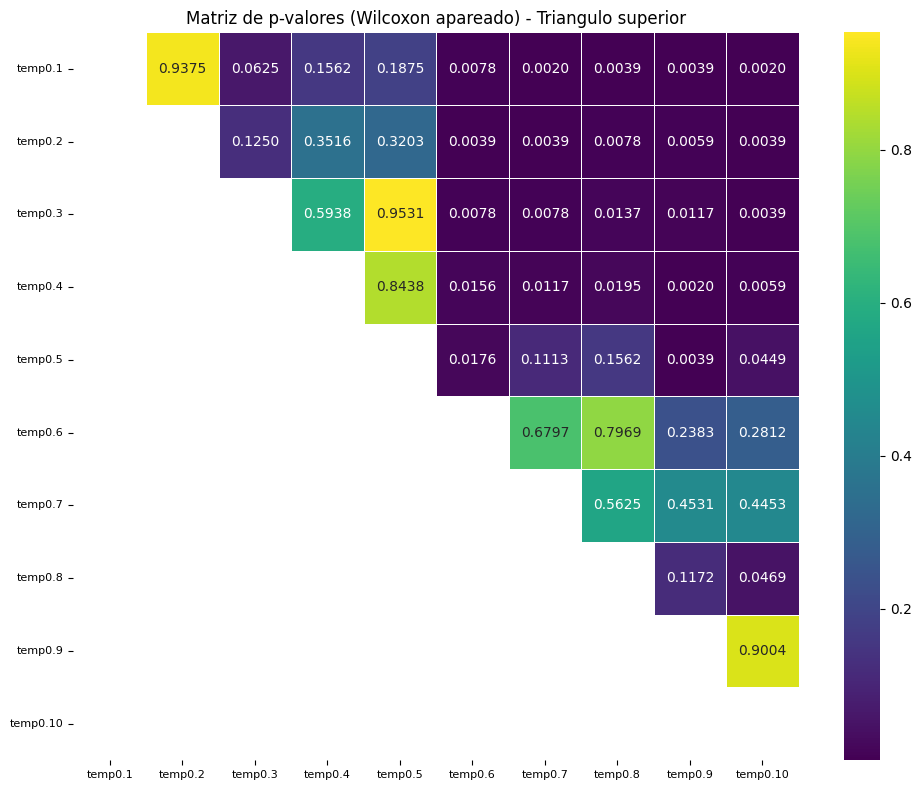

In [11]:
n_grupos = len(data_error) #obtiene la cantidad de datos que se tiene 
nombres_grupos = [f'temp0.{i+1}' for i in range(n_grupos)]

# inicializar matrices vacías
matriz_pvalores = np.full((n_grupos, n_grupos), np.nan)
matriz_estadisticos = np.full((n_grupos, n_grupos), np.nan)

for i in range(n_grupos):
    for j in range(i+1, n_grupos):
        statistic, p_value = stats.wilcoxon(data_error[i], data_error[j])
        matriz_pvalores[i, j] = p_value
        matriz_estadisticos[i, j] = statistic


# Crear DataFrames
df_pvalores = pd.DataFrame(matriz_pvalores, 
                          index=nombres_grupos, 
                          columns=nombres_grupos)

df_estadisticos = pd.DataFrame(matriz_estadisticos,
                              index=nombres_grupos,
                              columns=nombres_grupos)

print("=== MATRIZ DE VALORES p (Triángulo Superior) ===")
print(df_pvalores.round(4))
print("\n" + "="*50)

print("\n=== MATRIZ DE ESTADÍSTICOS W (Triángulo Superior) ===")
print(df_estadisticos.round(2))
print("\n" + "="*50)

plt.figure(figsize=(10, 8))
sns.heatmap(matriz_pvalores, 
                annot=True, fmt=".4f", 
                cmap="viridis", 
                cbar=True,
                linewidths=.5,
                xticklabels=nombres_grupos,  
                yticklabels=nombres_grupos)
    
plt.title('Matriz de p-valores (Wilcoxon apareado) - Triangulo superior', fontsize=12)
plt.xticks(rotation=0, fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.show()


In [ ]:
grupo0_1 = [15, 13, 14, 16, 14, 14, 15, 13, 14, 13]  # temp 0.1
grupo0_2 = [15, 17, 15, 13, 17, 14, 14, 12, 14, 12]  # temp 0.2
grupo0_3 = [15, 17, 16, 16, 16, 14, 15, 15, 14, 14]  # temp 0.3
grupo0_4 = [16, 15, 17, 14, 14, 17, 15, 13, 14, 15]  # temp 0.4
grupo0_5 = [13, 15, 19, 14, 16, 14, 15, 16, 22, 13]  # temp 0.5
grupo0_6 = [15, 22, 20, 16, 21, 18, 16, 18, 20, 15]  # temp 0.6
grupo0_7 = [21, 26, 16, 18, 17, 18, 22, 15, 18, 15]  # temp 0.7
grupo0_8 = [21, 19, 14, 17, 17, 18, 17, 18, 19, 17]  # temp 0.8
grupo0_9 = [21, 18, 23, 16, 15, 22, 21, 23, 25, 17]  # temp 0.9
grupo1_0 = [19, 22, 15, 21, 20, 25, 17, 18, 19, 23]  # temp 1.0

# Realizar la prueba H de Kruskal-Wallis
h_statistic, p_value = kruskal(grupo0_1, grupo0_2, grupo0_3, grupo0_4, grupo0_5, grupo0_6, grupo0_7, grupo0_8, grupo0_9, grupo1_0)

print(f"Estadístico H: {h_statistic}")
print(f"Valor p: {p_value}")


Estadístico H: 51.929639416929454
Valor p: 4.6609321333235464e-08



prueba Dunn para comparaciones post-hoc:
          0.1       0.2       0.3       0.4       0.5       0.6       0.7  \
0.1  1.000000  1.000000  1.000000  1.000000  1.000000  0.021698  0.012922   
0.2  1.000000  1.000000  1.000000  1.000000  1.000000  0.062664  0.041657   
0.3  1.000000  1.000000  1.000000  1.000000  1.000000  0.633737  0.450533   
0.4  1.000000  1.000000  1.000000  1.000000  1.000000  0.367251  0.251847   
0.5  1.000000  1.000000  1.000000  1.000000  1.000000  0.831893  0.633737   
0.6  0.021698  0.062664  0.633737  0.367251  0.831893  1.000000  1.000000   
0.7  0.012922  0.041657  0.450533  0.251847  0.633737  1.000000  1.000000   
0.8  0.025187  0.072924  0.676673  0.416329  0.914012  1.000000  1.000000   
0.9  0.000516  0.002347  0.053650  0.025187  0.080784  1.000000  1.000000   
1.0  0.000418  0.001937  0.046390  0.021698  0.072924  1.000000  1.000000   

          0.8       0.9       1.0  
0.1  0.025187  0.000516  0.000418  
0.2  0.072924  0.002347  0.001937  
0.

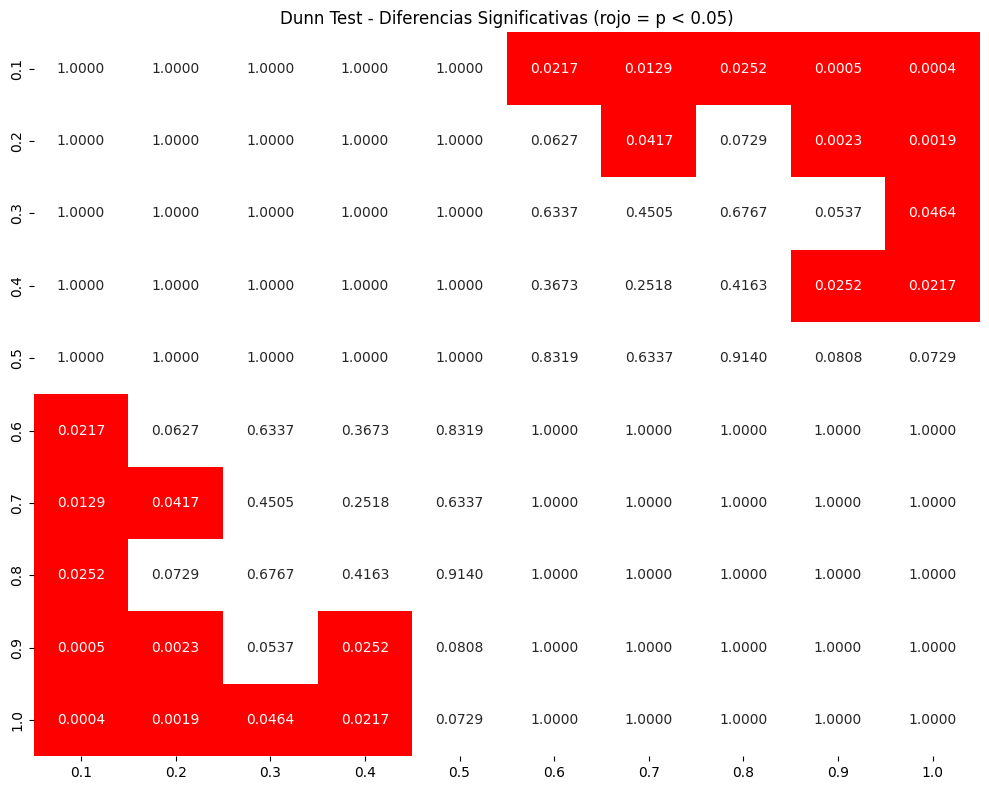

In [ ]:
# DataFrame con los datos y las etiquetas de grupo
datos_df_dunn = pd.DataFrame({
    'valor': np.concatenate([
        grupo0_1, grupo0_2, grupo0_3, grupo0_4, grupo0_5,
        grupo0_6, grupo0_7, grupo0_8, grupo0_9, grupo1_0
        ]),
    'grupo': ['0.1']*len(grupo0_1) + ['0.2']*len(grupo0_2) + ['0.3']*len(grupo0_3) +
            ['0.4']*len(grupo0_4) + ['0.5']*len(grupo0_5) + ['0.6']*len(grupo0_6) +
            ['0.7']*len(grupo0_7) + ['0.8']*len(grupo0_8) + ['0.9']*len(grupo0_9) + ['1.0']*len(grupo1_0)
})

# Se realiza la prueba de Dunn si el p-value de Kruskal-Wallis fue significativo
#p_adjust es el metodo de correccion 
dunn_results = sp.posthoc_dunn(datos_df_dunn, val_col='valor', group_col='grupo', p_adjust='holm') 
print("\nprueba Dunn para comparaciones post-hoc:")
print(dunn_results)

#si valor p es menor que 0.05 -- diferencias significativas en esa comparacion

plt.figure(figsize=(10, 8))
sns.heatmap(dunn_results < 0.05, annot=dunn_results.round(4), 
            cmap=['white', 'red'], fmt='.4f', cbar=False)
plt.title('Dunn Test - Diferencias Significativas (rojo = p < 0.05)')
plt.tight_layout()
plt.show()

In [37]:
model = ols('temp ~ errores', data=data).fit()
anova_table = sm.stats.anova_lm(model, typ=2)
print("ANOVA:")
print(anova_table)

ANOVA:
            sum_sq    df          F        PR(>F)
errores   3.577425   1.0  75.030914  9.620005e-14
Residual  4.672575  98.0        NaN           NaN
